In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

# Libraries and imports:

In [2]:
import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import wandb
from sklearn.metrics import accuracy_score, f1_score

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
os.environ["WANDB_API_KEY"] = secret_value_0

In [4]:
wandb.login()

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

# EDA:

Sample rate: 44100
Duration (sec): 30.013333333333332


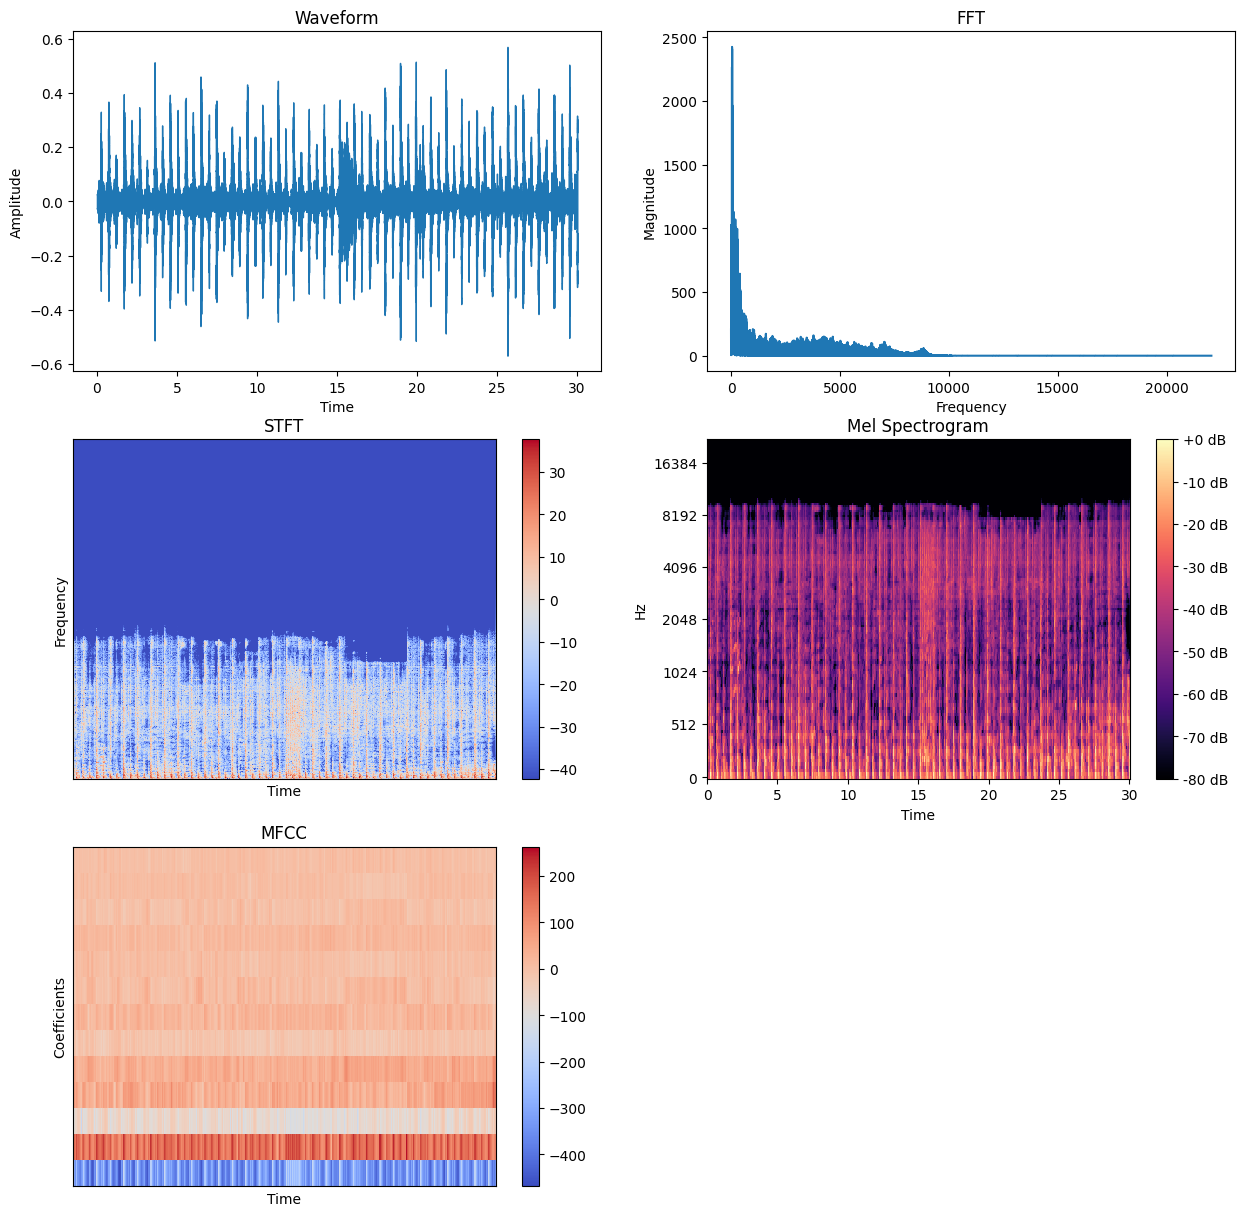

In [5]:
# Train data

import librosa.display

example_file = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000/drums.wav"

y, sr = librosa.load(example_file, sr=None)
print("Sample rate:", sr)
print("Duration (sec):", len(y)/sr)

plt.figure(figsize=(15,15))

plt.subplot(3,2,1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(3,2,2)
fft = np.fft.fft(y)
magnitude = np.abs(fft)
frequency = np.linspace(0, sr, len(magnitude))
left_frequency = frequency[:int(len(frequency)/2)]
left_magnitude = magnitude[:int(len(magnitude)/2)]
plt.plot(left_frequency, left_magnitude)
plt.title("FFT")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")

plt.subplot(3,2,3)
stft = librosa.core.stft(y, hop_length=512, n_fft=2048)
spectogram = np.abs(stft)
log_spectogram = librosa.amplitude_to_db(spectogram)
librosa.display.specshow(log_spectogram, sr=sr, hop_length=512)
plt.title("STFT")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()

plt.subplot(3,2,4)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")

plt.subplot(3,2,5)
mfcc = librosa.feature.mfcc(y=y, hop_length=512, n_fft=2048, n_mfcc=13)
librosa.display.specshow(mfcc, sr=sr, hop_length=512)
plt.title("MFCC")
plt.xlabel("Time")
plt.ylabel("Coefficients")
plt.colorbar()

plt.show()

Mashup sample rate: 22050
Mashup duration: 30.00018140589569


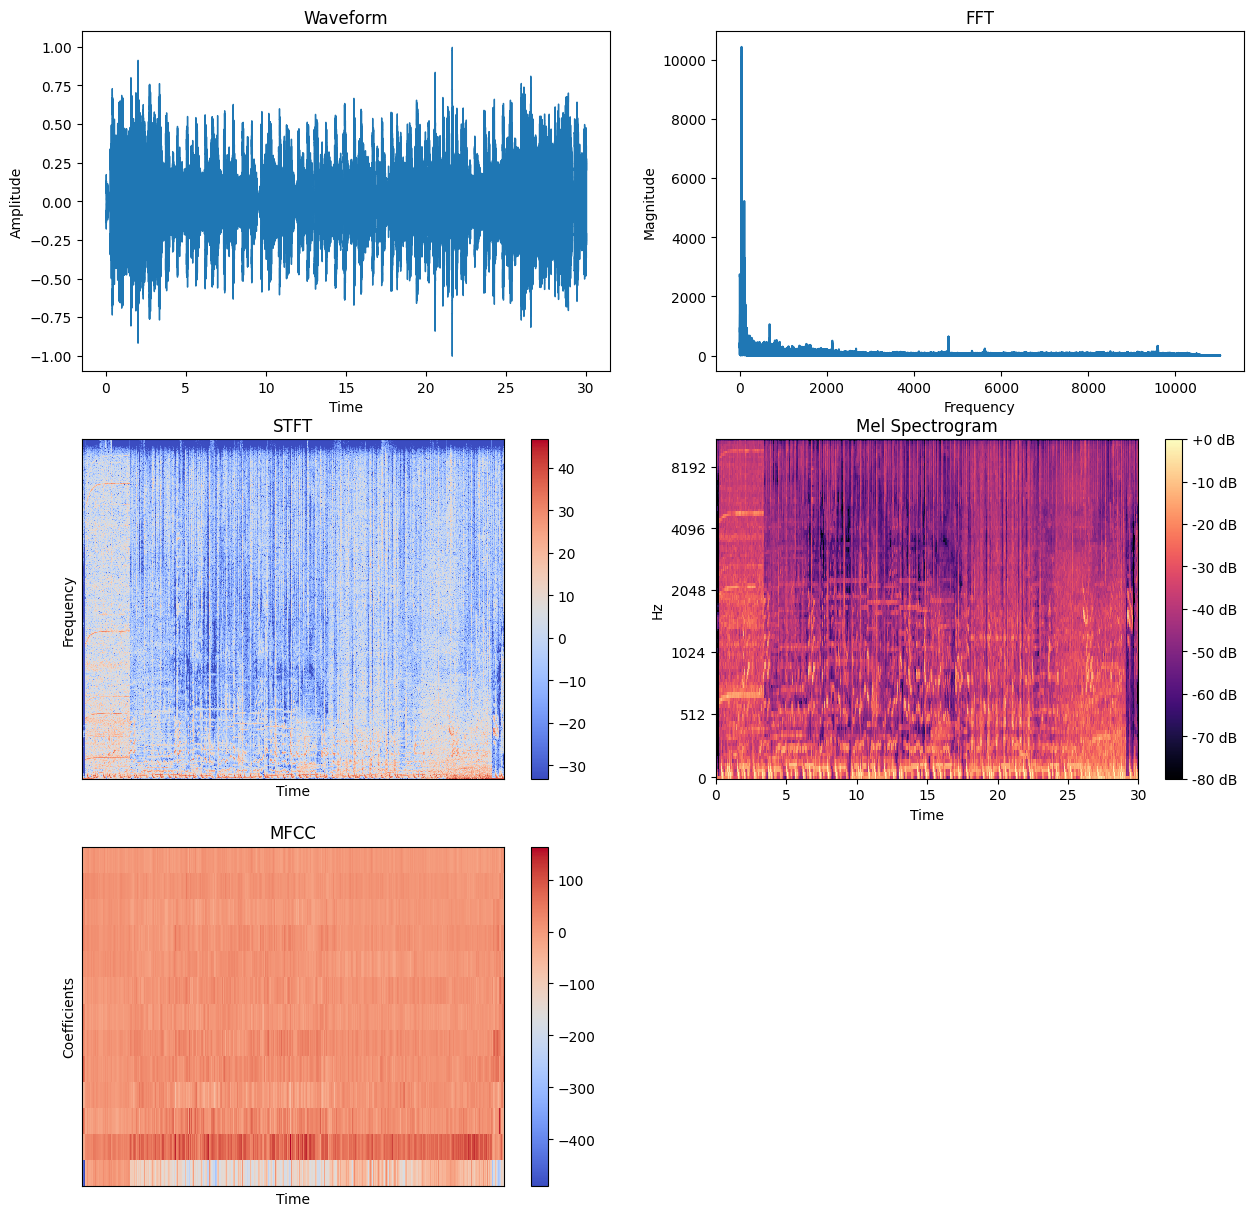

In [6]:
# Test data

test_eg = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/song0001.wav"
y, sr = librosa.load(test_eg, sr=None)
print("Mashup sample rate:", sr)
print("Mashup duration:", len(y)/sr)

plt.figure(figsize=(15,15))

plt.subplot(3,2,1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(3,2,2)
fft = np.fft.fft(y)
magnitude = np.abs(fft)
frequency = np.linspace(0, sr, len(magnitude))
left_frequency = frequency[:int(len(frequency)/2)]
left_magnitude = magnitude[:int(len(magnitude)/2)]
plt.plot(left_frequency, left_magnitude)
plt.title("FFT")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")

plt.subplot(3,2,3)
stft = librosa.core.stft(y, hop_length=512, n_fft=2048)
spectogram = np.abs(stft)
log_spectogram = librosa.amplitude_to_db(spectogram)
librosa.display.specshow(log_spectogram, sr=sr, hop_length=512)
plt.title("STFT")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()

plt.subplot(3,2,4)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")

plt.subplot(3,2,5)
mfcc = librosa.feature.mfcc(y=y, hop_length=512, n_fft=2048, n_mfcc=13)
librosa.display.specshow(mfcc, sr=sr, hop_length=512)
plt.title("MFCC")
plt.xlabel("Time")
plt.ylabel("Coefficients")
plt.colorbar()

plt.show()

In [7]:
# DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
# GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
# STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

# train_srs = []
# train_durations = []
# train_silence = []
# train_rms = []

# for genre in tqdm(GENRES):
#     genre_path = os.path.join(DATA_PATH, genre)
    
#     for song in os.listdir(genre_path):
#         song_path = os.path.join(genre_path, song)

#         for stem in STEMS:
#             audio_path = os.path.join(song_path, stem)

#             y, sr = librosa.load(audio_path, sr=None)
#             duration = len(y) / sr
#             silence_ratio = np.mean(np.abs(y) < 1e-4)
#             rms = np.mean(librosa.feature.rms(y=y))
            
#             train_srs.append(sr)
#             train_durations.append(duration)
#             train_silence.append(silence_ratio)
#             train_rms.append(rms)

# print("Train unique SRs:", set(train_srs))
# print("Train duration mean:", np.mean(train_durations))
# print("Train duration std:", np.std(train_durations))
# print("Train silence mean:", np.mean(train_silence))
# print("Train RMS mean:", np.mean(train_rms))

# Train unique SRs: {44100}
# Train duration mean: 30.02404707482993
# Train duration std: 0.08087336094347475
# Train silence mean: 0.16854941092207973
# Train RMS mean: 0.04491053

In [8]:
# mashup_path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups"

# test_srs = []
# test_durations = []
# test_silence = []
# test_rms = []

# for song in tqdm(os.listdir(mashup_path)):
#     audio_path = os.path.join(mashup_path, song)

#     y, sr = librosa.load(audio_path, sr=None)
    
#     duration = len(y) / sr
#     silence_ratio = np.mean(np.abs(y) < 1e-4)
#     rms = np.mean(librosa.feature.rms(y=y))
    
#     test_srs.append(sr)
#     test_durations.append(duration)
#     test_silence.append(silence_ratio)
#     test_rms.append(rms)

# print("Test unique SRs:", set(test_srs))
# print("Test duration mean:", np.mean(test_durations))
# print("Test duration std:", np.std(test_durations))
# print("Test silence mean:", np.mean(test_silence))
# print("Test RMS mean:", np.mean(test_rms))

# Test unique SRs: {22050}
# Test duration mean: 28.653239927317504
# Test duration std: 3.772994605159907
# Test silence mean: 0.0009087508105784579
# Test RMS mean: 0.12791249

# Train-Validation Split:

For each genre:<br>
100 songs<br>
&emsp;&emsp;Split into:<br>
&emsp;&emsp;&emsp;80 songs → train pool<br>
&emsp;&emsp;&emsp;20 songs → validation pool<br>

In [9]:
GENRES_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
genres = sorted(os.listdir(GENRES_PATH))
random.seed(42)

train_songs = {}
val_songs = {}

for genre in genres:
    genre_path = os.path.join(GENRES_PATH, genre)
    songs = os.listdir(genre_path)

    random.shuffle(songs)

    train_songs[genre] = songs[:int(0.8*len(songs))]
    val_songs[genre] = songs[int(0.8*len(songs)):]

print("Example:")
print("Genre name:", genres[0], "\nTrain:", len(train_songs[genres[0]]), 
      "\nVal:", len(val_songs[genres[0]]), "\nTrain songs:", train_songs[genres[0]])

Example:
Genre name: blues 
Train: 80 
Val: 20 
Train songs: ['blues.00058', 'blues.00029', 'blues.00014', 'blues.00008', 'blues.00009', 'blues.00000', 'blues.00006', 'blues.00091', 'blues.00099', 'blues.00059', 'blues.00052', 'blues.00012', 'blues.00072', 'blues.00026', 'blues.00055', 'blues.00093', 'blues.00036', 'blues.00096', 'blues.00015', 'blues.00078', 'blues.00010', 'blues.00011', 'blues.00027', 'blues.00085', 'blues.00094', 'blues.00049', 'blues.00069', 'blues.00030', 'blues.00003', 'blues.00050', 'blues.00016', 'blues.00020', 'blues.00022', 'blues.00076', 'blues.00089', 'blues.00048', 'blues.00064', 'blues.00034', 'blues.00018', 'blues.00092', 'blues.00033', 'blues.00053', 'blues.00037', 'blues.00082', 'blues.00041', 'blues.00031', 'blues.00075', 'blues.00083', 'blues.00024', 'blues.00013', 'blues.00066', 'blues.00038', 'blues.00056', 'blues.00086', 'blues.00001', 'blues.00044', 'blues.00079', 'blues.00043', 'blues.00084', 'blues.00005', 'blues.00004', 'blues.00074', 'blues.0

# Creating Dataset:

## Noise file:

In [10]:
ESC_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio"

noise_files = []

for file in os.listdir(ESC_PATH):
    if file.endswith(".wav"):
        noise_files.append(os.path.join(ESC_PATH, file))

print("Total noise files:", len(noise_files))

Total noise files: 2000


## Preprocessing:

In [11]:
def load_audio(path, sr):
    y, _ = librosa.load(path, sr=sr)
    return y


def random_crop(y, samples_required):
    if len(y) <= samples_required:
        num_padding = samples_required - len(y)
        y = np.pad(y, (0, num_padding))
        return y
        
    starting_point = random.randint(0, len(y) - samples_required)
    y = y[starting_point : starting_point + samples_required]
    return y
    

def center_crop(y, samples_required):
    if len(y) <= samples_required:
        num_padding = samples_required - len(y)
        y = np.pad(y, (0, num_padding))
        return y

    starting_point = (len(y) - samples_required)//2
    y = y[starting_point : starting_point + samples_required]
    return y
    

def add_noise(y, noise_files, sr, samples_required):
    noise_path = random.choice(noise_files)
    noise = load_audio(noise_path, sr)
    noise = random_crop(noise, samples_required)
    # Normalizing (different noises can have different loudness levels)
    noise = noise / (np.max(np.abs(noise)) + 1e-6) # adding 1e-6 to prevent division by zero error
    # Scaling the noise down so it won't overpower the music
    noise = noise * random.uniform(0.05, 0.2)

    return y + noise
    

def preprocess(bass_path, drums_path, other_path, vocals_path, noise_files, sr=16000, duration=5, n_fft=1024, hop_length=160, n_mels=128, train=True):
    samples_needed = sr * duration

    bass = load_audio(bass_path, sr=sr)
    drums = load_audio(drums_path, sr=sr)
    other = load_audio(other_path, sr=sr)
    vocals = load_audio(vocals_path, sr=sr)

    if train:
        # random gain/scaling for robustness
        bass *= random.uniform(0.6, 1.4)
        drums *= random.uniform(0.6, 1.4)
        other *= random.uniform(0.6, 1.4)
        vocals *= random.uniform(0.6, 1.4)

    min_length = min(len(bass), len(drums), len(other), len(vocals))

    mixed = (
        bass[:min_length] +
        drums[:min_length] +
        other[:min_length] +
        vocals[:min_length]
    )

    if train:
        mixed = random_crop(mixed, samples_needed)       
        if random.random() < 0.3: # 30% probability
            mixed = add_noise(mixed, noise_files, sr, samples_needed)
    else: 
        mixed = center_crop(mixed, samples_needed)

    # Normalizing to prevent loudness bias
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-6) # adding 1e-6 to prevent division by zero error

    mel = librosa.feature.melspectrogram(
        y=mixed,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    log_mel = librosa.power_to_db(mel, ref=np.max)

    return torch.tensor(log_mel).unsqueeze(0).float()

## Train and Validation set:

In [12]:
# GENRES_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
# genres = sorted(os.listdir(GENRES_PATH))

# random.seed(42)

# train_paths = []
# train_labels = []
# train_genres = []
# TRAIN_PER_GENRE = 3000

# for genre_id, genre in enumerate(genres):
#     train_song_list = train_songs[genre]

#     train_dir = f"processed_dataset/train/{genre_id}"
#     os.makedirs(train_dir, exist_ok=True)

#     for i in tqdm(range(TRAIN_PER_GENRE), desc=f"Train {genre}"):
#         song1, song2, song3, song4 = random.sample(train_song_list, 4)

#         bass_path = os.path.join(GENRES_PATH, genre, song1, "bass.wav")
#         drums_path = os.path.join(GENRES_PATH, genre, song2, "drums.wav")
#         other_path = os.path.join(GENRES_PATH, genre, song3, "other.wav")
#         vocals_path = os.path.join(GENRES_PATH, genre, song4, "vocals.wav")

#         tensor = preprocess(
#             bass_path,
#             drums_path,
#             other_path,
#             vocals_path,
#             noise_files=noise_files,
#             train=True
#         )

#         save_path = os.path.abspath(os.path.join(train_dir, f"{genre_id}_{i}.pt"))
#         torch.save(tensor, save_path)

#         train_paths.append(save_path)
#         train_labels.append(genre_id)
#         train_genres.append(genre)


# val_paths = []
# val_labels = []
# val_genres = []
# VAL_PER_GENRE = 750

# for genre_id, genre in enumerate(genres):

#     val_song_list = val_songs[genre]

#     val_dir = f"processed_dataset/val/{genre_id}"
#     os.makedirs(val_dir, exist_ok=True)

#     for i in tqdm(range(VAL_PER_GENRE), desc=f"Val {genre}"):

#         song1, song2, song3, song4 = random.sample(val_song_list, 4)

#         bass_path = os.path.join(GENRES_PATH, genre, song1, "bass.wav")
#         drums_path = os.path.join(GENRES_PATH, genre, song2, "drums.wav")
#         other_path = os.path.join(GENRES_PATH, genre, song3, "other.wav")
#         vocals_path = os.path.join(GENRES_PATH, genre, song4, "vocals.wav")

#         tensor = preprocess(
#             bass_path,
#             drums_path,
#             other_path,
#             vocals_path,
#             noise_files=noise_files,
#             train=False
#         )
        
#         save_path = os.path.abspath(os.path.join(val_dir, f"{genre_id}_{i}.pt"))
#         torch.save(tensor, save_path)

#         val_paths.append(save_path)
#         val_labels.append(genre_id)
#         val_genres.append(genre)
        

# os.makedirs("metadata", exist_ok=True)

# df_train = pd.DataFrame({
#     "path": train_paths,
#     "genre": train_genres,
#     "label": train_labels,
# })

# df_val = pd.DataFrame({
#     "path": val_paths,
#     "genre": val_genres,
#     "label": val_labels,
# })

# df_train.to_csv("metadata/train_metadata.csv", index=False)
# df_val.to_csv("metadata/val_metadata.csv", index=False)

In [13]:
!ls

__notebook__.ipynb


In [14]:
# df_train = pd.read_csv("/kaggle/working/metadata/train_metadata.csv")
# df_val = pd.read_csv("/kaggle/working/metadata/val_metadata.csv")

# print("Train data:")
# display(df_train.head())
# print(df_train.shape)
# print("\n\nVal data:")
# display(df_val.head())
# print(df_val.shape)

## Test set:

In [15]:
df_test = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv")
display(df_test.head())
df_test.shape

,id,filename
0,1,mashups/song0001.wav
1,2,mashups/song0002.wav
2,3,mashups/song0003.wav
3,4,mashups/song0004.wav
4,5,mashups/song0005.wav


(3020, 2)

In [16]:
# test_paths = []
# test_ids = []

# os.makedirs("processed_dataset/test_waveforms", exist_ok=True)

# for _, row in tqdm(df_test.iterrows(), total=len(df_test)):

#     audio_path = os.path.join(
#         "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup",
#         row["filename"]
#     )

#     y, _ = librosa.load(audio_path, sr=16000)

#     tensor = torch.tensor(y).float()

#     save_path = os.path.abspath(f"processed_dataset/test_waveforms/{row['id']}.pt")

#     torch.save(tensor, save_path)

#     test_paths.append(save_path)
#     test_ids.append(row["id"])

# os.makedirs("metadata", exist_ok=True)

# df_test = pd.DataFrame({
#     "id": test_ids,
#     "path": test_paths
# })

# df_test.to_csv("metadata/test_metadata.csv", index=False)

In [17]:
# df_test = pd.read_csv("/kaggle/working/metadata/test_metadata.csv")
# display(df_test.head())
# print(df_test.shape)

# Dataset and DataLoader:

## Train and Validation Dataset:

In [18]:
# class Train_Val_Dataset(Dataset):
#     def __init__(self, df):
#         self.df = df

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         x = torch.load(row["path"])
#         y = torch.tensor(row["label"])

#         return x, y

In [19]:
# train_dataset = Train_Val_Dataset(df_train)
# val_dataset   = Train_Val_Dataset(df_val)

# x, y = train_dataset[0]
# print(f"Train shape: {x.shape}, label: {y}")

## Test Dataset:

In [20]:
# class TestDataset(Dataset):
#     def __init__(self, df):
#         self.df = df

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         waveform = torch.load(row["path"])

#         return waveform, row["id"]

In [21]:
# test_dataset = TestDataset(df_test)

# y, idx = test_dataset[0]

# print(len(y))
# print(idx)

## DataLoader:

In [22]:
# BATCH_SIZE = 128

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)

# for x, y in train_loader:
#     print(x.shape, y.shape)
#     break

# Models:

## 1. ScratchCNN:

In [23]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv_layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2)
        ) # output: (64, 32, 64, 108)

        self.conv_layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2)
        ) # output: (64, 64, 32, 54)

        self.conv_layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2)
        ) # output: (64, 128, 16, 27)

        self.conv_layer4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1) # output: (64, 128, 1, 1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), # without global pool -> (128*16*27, 64)
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.conv_layer2(x)
        x = self.conv_layer3(x)
        x = self.conv_layer4(x)
        
        x = self.global_pool(x)
        x = self.fc(x)

        return x

In [24]:
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(DEVICE)

# model = ScratchCNN(num_classes=10).to(DEVICE)
# print(model)

# Loss function, Optimizer and Metrics:

In [25]:
# criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='max',      # because we monitor F1
#     factor=0.5,
#     patience=2
# )

# Training and Validation:

In [26]:
# wandb.init(
#     entity="23f1002354-dl-genai-project",
#     project="23f1002354-t12026",
#     name="ScratchCNN_1",
#     config={
#         "epochs": 15,
#         "batch_size": 64,
#         "lr": 1e-3,
#         "model": "ScratchCNN"
#     }
# )

In [27]:
# EPOCHS = 15

# for epoch in range(EPOCHS):
    
#     ############
#     # Training #
#     ############
    
#     model.train()
    
#     train_loss = 0
#     train_preds = []
#     train_labels = []
    
#     for x, y in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}", leave=False): 
#         x, y = x.to(DEVICE), y.to(DEVICE)
        
#         optimizer.zero_grad()
#         y_pred = model(x)
#         loss = criterion(y_pred, y)
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item()
#         train_pred = torch.argmax(y_pred, dim=1)
#         train_preds.extend(train_pred.cpu().numpy())
#         train_labels.extend(y.cpu().numpy())

#     train_avg_loss = train_loss / len(train_loader)
#     train_acc = accuracy_score(train_labels, train_preds)
#     print(f"[Train] Epoch {epoch+1}: Loss={train_avg_loss:.4f}, Accuracy score={train_acc:.4f}")
    
#     ##############
#     # Validation #
#     ##############
    
#     model.eval()
    
#     val_loss = 0
#     val_preds = []
#     val_labels = []
    
#     with torch.no_grad():
#         for x, y in tqdm(val_loader, desc=f"[Val] Epoch {epoch+1}", leave=False):
#             x, y = x.to(DEVICE), y.to(DEVICE)

#             y_pred = model(x)
#             loss = criterion(y_pred, y)

#             val_loss += loss.item()
#             val_pred = torch.argmax(y_pred, dim=1)
#             val_preds.extend(val_pred.cpu().numpy())
#             val_labels.extend(y.cpu().numpy())

#     val_avg_loss = val_loss / len(val_loader)
#     val_acc = accuracy_score(val_labels, val_preds)
#     val_f1 = f1_score(val_labels, val_preds, average="macro")
#     print(f"[val] Epoch {epoch+1}: Loss={val_avg_loss:.4f}, Accuracy score={val_acc:.4f}, F1 macro score={val_f1:.4f}")

#     scheduler.step(val_f1)
    
#     wandb.log({
#         "train_avg_loss": train_avg_loss,
#         "train_accuracy": train_acc,
#         "val_avg_loss": val_avg_loss,
#         "val_accuracy": val_acc,
#         "val_macro_f1": val_f1,
#         "learning_rate": optimizer.param_groups[0]["lr"]
#     })

# wandb.finish()